In [1]:
import time
import warnings
import datetime
from dataclasses import dataclass
from typing import Tuple, List

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from category_encoders import CountEncoder, TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    GridSearchCV,
)
from sklearn.linear_model import (
    LogisticRegression,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    auc,
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
RANDOM_STATE: int = 42

| Item          | Version  |
|-------------------|---------|
| Kernel            | Python 3.12.0 |
| sklearn           | 1.7.1   |
| pandas            | 2.3.2   |
| seaborn           | 0.13.2  |
| matplotlib        | 3.10.6  |
| code formatter    | black 25.1.0  |

In [2]:
notebook_time = time.time()

#### 1. Download data from Don’tGetKicked competition.

kaggle competitions download -c DontGetKicked<br>
or direct download

##### 1.1 Read all the data

In [3]:
path: str = "data/DontGetKicked/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(path.format(name="training"), parse_dates=["PurchDate"])
test_df: pd.DataFrame = pd.read_csv(path.format(name="test"), parse_dates=["PurchDate"])

##### 1.2 Drop columns with N/A > 50%

In [4]:
NA_THRESHOLD: float = 0.5
NA_percent = train_df.isnull().mean()
to_drop = NA_percent[NA_percent >= NA_THRESHOLD].index
train_df_wo_na = train_df.drop(columns=to_drop)

##### 1.3 Simple impute N/A for other columns and scale numeric

In [5]:
TARGET: str = "IsBadBuy"
DATETIME_COL: str = "PurchDate"
numeric = (
    train_df_wo_na.drop(TARGET, axis=1)
    .select_dtypes(exclude=["object", "datetime"])
    .columns
)

categories = train_df_wo_na.select_dtypes(include="object").columns

numeric_pipeline = Pipeline(
    [
        ("num_imp", SimpleImputer(strategy="median")),
        ("st_scaler", StandardScaler()),
    ]
)

categories_pipeline = Pipeline(
    [
        ("cat_imp", SimpleImputer(strategy="constant", fill_value="unknown")),
    ]
)

col_tr = ColumnTransformer(
    transformers=[
        ("num_pipeline", numeric_pipeline, numeric),
        ("cat_pipeline", categories_pipeline, categories),
    ],
    remainder="drop",
)
train_df_tform_arr = col_tr.fit_transform(train_df_wo_na)

train_df_tform = pd.DataFrame(train_df_tform_arr)
train_df_tform.columns = numeric.to_list() + categories.to_list()
# add target and datetime col to final df
train_df_tform[DATETIME_COL] = train_df_wo_na[DATETIME_COL]
train_df_tform[TARGET] = train_df_wo_na[TARGET]

#### 2. Design the train/validation/test split. <br>Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. <br>Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [6]:
def split_by_date_percentiles(
    X: pd.DataFrame,
    shift: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    info = X.dtypes
    date_in_df = [pd.api.types.is_datetime64_ns_dtype(x) for x in info.values]
    if not any(date_in_df):
        raise ValueError("No date col in df")

    date_col = info.index[date_in_df.index(True)]

    X = X.sort_values(by=date_col)

    unique_dates = X[date_col].unique()
    n_dates = len(unique_dates)

    train_threshold = unique_dates[n_dates // 3 + shift]
    val_threshold = unique_dates[2 * n_dates // 3 + shift]

    X_train = X[X[date_col] <= train_threshold]
    X_valid = X[(X[date_col] > train_threshold) & (X[date_col] <= val_threshold)]
    X_test = X[X[date_col] > val_threshold]

    assert X_train[date_col].max() < X_valid[date_col].min()
    assert X_valid[date_col].max() < X_test[date_col].min()

    return X_train, X_valid, X_test


def check_split(df_list: List[pd.DataFrame], df_initial: pd.DataFrame) -> None:
    final_set: set = set(df_initial.index)
    for df in df_list:
        final_set -= set(df.index)
    print(final_set == set())
    [print(round(len(x) / len(df_initial), 2), end=" ") for x in df_list]


X_train, X_valid, X_test = split_by_date_percentiles(train_df_tform, shift=8)
check_split(df_list=[X_train, X_valid, X_test], df_initial=train_df_tform)

True
0.33 0.33 0.33 

#### 3. Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables. Be careful with data leakage (fit Encoder to training and apply to validation & test). Consider another coding approach if you encounter new categorical values in validation & test (not seen in training): https://contrib.scikit-learn.org/category_encoders/count.html

In [7]:
cat_to_onehot_enc: list = []
cat_to_count_enc: list = []

for category in categories:
    # if there is many unique values we cant use OHE
    if X_train[category].value_counts().count() < 21:
        cat_to_onehot_enc.append(category)
    else:
        cat_to_count_enc.append(category)

# to avoid dummy variable trap use drop='first'
# when feature matrix becomes singular (determinant = 0)
one_hot_enc = OneHotEncoder(
    sparse_output=False,
    drop="first",
    feature_name_combiner="concat",
    handle_unknown="ignore",
)
cat_one_hot_enc = one_hot_enc.fit(X_train[cat_to_onehot_enc])

count_enc = CountEncoder(normalize=True, min_group_size=15)
cat_count_enc = count_enc.fit(X_train[cat_to_count_enc])

df_transformed: list = []

for df in [X_train, X_valid, X_test]:
    cat_one_hot_enc = one_hot_enc.transform(df[cat_to_onehot_enc])
    cat_one_hot_enc = pd.DataFrame(
        cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
    )

    cat_count_enc = count_enc.transform(df[cat_to_count_enc])
    combined = pd.concat(
        [
            df[numeric].reset_index(drop=True),
            cat_count_enc.reset_index(drop=True),
            cat_one_hot_enc.reset_index(drop=True),
            df[TARGET].reset_index(drop=True),
        ],
        axis=1,
    )
    df_transformed.append(combined)

X_train, X_valid, X_test = df_transformed

In [8]:
y_train = X_train[TARGET]
X_train = X_train.drop(TARGET, axis=1).astype(np.float64)
y_valid = X_valid[TARGET]
X_valid = X_valid.drop(TARGET, axis=1).astype(np.float64)
y_test = X_test[TARGET]
X_test = X_test.drop(TARGET, axis=1).astype(np.float64)

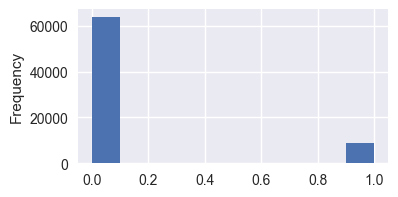

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 2))
train_df[TARGET].plot.hist(ax=ax)
fig.show()

Target classes are imbalanced

#### 4. Train LogisticRegression, GaussianNB, KNN from sklearn on the training dataset and check the quality of your algorithms on the validation dataset. <br>The dependent variable (IsBadBuy) is binary. Don't forget to normalize your datasets before training your models.

You must get at least 0.15 Gini score (the best of all three). Which algorithm performs better? And why?


In [10]:
def out_log_nb_knn_gini(X_train, y_train, X_valid, y_valid) -> pd.DataFrame:
    out: pd.DataFrame = pd.DataFrame({"model": [], "Gini": []})

    for model in LogisticRegression(), GaussianNB(), KNeighborsClassifier():
        model.fit(X=X_train, y=y_train)
        # by [:,1] we get pos observation
        y_pred = model.predict_proba(X=X_valid)[:, 1]
        # using 2*ROC AUC - 1 approach
        out.loc[len(out)] = {
            "model": model,
            "Gini": round(2 * roc_auc_score(y_true=y_valid, y_score=y_pred) - 1, 4),
        }

    display(out.sort_values(by="Gini", ascending=False).reset_index(drop=True))
    return out


start_out = out_log_nb_knn_gini(
    X_train=X_train, y_train=y_train, X_valid=X_valid, y_valid=y_valid
)

,model,Gini
0,LogisticRegression(),0.4261
1,GaussianNB(),0.4248
2,KNeighborsClassifier(),0.2267


Difference between GaussianNB and LogisticRegression isn't significat so they are the best algoes.<br>
Why? Beacause of preprocessing: StandardScaler and CountEncoder is suited (robust) for these algos.<br>
For KNN our preprocessing is not suitable: sensitive for sparsity after OneHotEncoder<br>
(for GaussianNB and Logistic seems not)

#### 5. Implement Gini score calculation. <br>You can use the 2*ROC AUC - 1 approach, so you need to implement the ROC AUC calculation. <br>Check if your metric is approximately equal to abs(2*sklearn.metrics.roc_auc_score - 1).

In [11]:
def plot_roc(false_pos_rate, true_pos_rate) -> None:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(false_pos_rate, true_pos_rate, label="ROC curve")
    ax.plot([0, 1], [0, 1], linestyle="--", c="gray")

    ax.set_title("ROC cruve plot", fontsize=16)
    ax.set_xlabel("FP rate", fontsize=16)
    ax.set_ylabel("TP rate", fontsize=16)
    ax.legend()
    ax.grid()

In [12]:
def roc_auc(y_true, y_score):
    """
    ROC AUC stands for Receiver Operating Characteristic Area Under the Curve
    """
    sorted_idx = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[sorted_idx]
    true_pos_rate, false_pos_rate = [0], [0]
    True_Pos, False_Pos = 0, 0
    Pos = sum(y_true)
    Neg = len(y_true) - Pos

    for i in range(len(y_true_sorted)):
        if y_true_sorted[i]:
            True_Pos += 1
        else:
            False_Pos += 1

        true_pos_rate.append(True_Pos / Pos)
        false_pos_rate.append(False_Pos / Neg)

    # or use np.trapz(true_pos_rate, false_pos_rate)
    auc_score = 0
    for i in range(1, len(false_pos_rate)):
        auc_score += (
            (false_pos_rate[i] - false_pos_rate[i - 1])
            * (true_pos_rate[i] + true_pos_rate[i - 1])
            / 2
        )

    return auc_score, (false_pos_rate, true_pos_rate)


def gini_score(y_true, y_score):
    """using 2*ROC AUC - 1 approach"""
    return 2 * roc_auc(y_true=y_true, y_score=y_score)[0] - 1


def gini_score_sk(y_true, y_score):
    """using 2*ROC AUC - 1 approach"""
    return round(2 * roc_auc_score(y_true=y_true, y_score=y_score) - 1, 4)

,model,roc_auc,Gini
0,LogisticRegression(),0.7130,0.4261
1,LogisticRegression_my,0.7130,0.4261
2,GaussianNB(),0.7124,0.4248
3,GaussianNB_my,0.7123,0.4246
4,KNeighborsClassifier(),0.6134,0.2267
5,KNeighborsClassifier_my,0.6243,0.2485


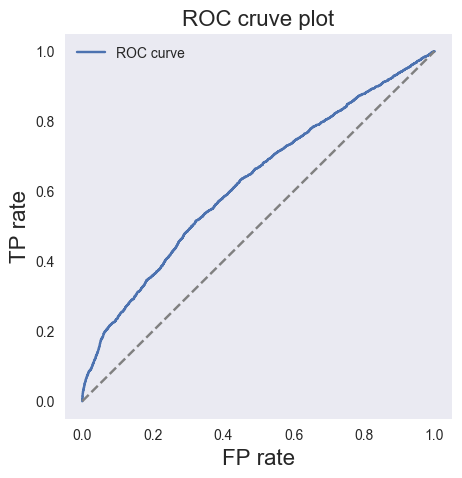

In [13]:
# check roc_auc and gini implementation
out: pd.DataFrame = pd.DataFrame({"model": [], "roc_auc": [], "Gini": []})

for model in LogisticRegression(), GaussianNB(), KNeighborsClassifier():
    model.fit(X=X_train, y=y_train)
    # by [:,1] we get pos observation
    y_pred = model.predict_proba(X=X_valid)[:, 1]
    # using 2*ROC AUC - 1 approach
    out.loc[len(out)] = {
        "model": model,
        "roc_auc": round(roc_auc_score(y_true=y_valid, y_score=y_pred), 4),
        "Gini": round(gini_score_sk(y_true=y_valid.values, y_score=y_pred), 4),
    }
    out.loc[len(out)] = {
        "model": f"{model.__class__.__name__}_my",
        "roc_auc": round(roc_auc(y_true=y_valid.values, y_score=y_pred)[0], 4),
        "Gini": round(gini_score(y_true=y_valid.values, y_score=y_pred), 4),
    }

display(out.reset_index(drop=True))
plot_roc(*roc_auc(y_true=y_valid.values, y_score=y_pred)[1])

![pic5](../misc/images/precision.png)

#### 6. Implement your own versions of LogisticRegression, KNN and NaiveBayes classifiers.<br> For LogisticRegression compute gradients with respect to the loss and use stochastic gradient descent. <br> Can you reproduce the results from step 4?

Guidance for this task: Your model must be represented by class with methods fit, predict (predict_proba with 0.5 threshold), predict_proba.<br>
For LR moder, compute the loss gradient with respect to parameters w and parameter b in the fit function.<br>
Use a simple SGD approach to estimate optimal values of parameters.

### Sigmoid<br> $\sigma(z) = \frac{1}{1 + e^{-\langle w,x_i \rangle}} = \frac{1}{1 + e^{-z}}$
####
#### Loss func<br> $L_{\text{min}}(w,X,y) = -\sum_{i} \left( y_i \log(\sigma(\langle w,x_i \rangle)) + (1-y_i) \log(\sigma(-\langle w,x_i \rangle)) \right)$
#### Gradient<br> $\nabla_w L(y,X,w) = -\sum_{i} x_i \left( y_i - \sigma(\langle w,x_i \rangle) \right)$

In [14]:
@dataclass
class LogisticRegression_SGD:
    """
    Stochastic Gradient Descent for Logistic regression
    Algorithm complexity (Fit): O(epoch * n_train_samples * n_features)
    Algorithm complexity (Predict): O(n_test_samples * n_features)
    """

    fit_intercept: bool = True
    learning_rate: float = 0.01
    batch_size: int = 10_000
    epoch: int = 100
    tolerance: float = 1e-04
    random_state: int = 42
    l2_penalty: float = 0.0

    def fit(self, X, y):
        # shuffle X, y
        X = X.copy(deep=True)
        X = X.sample(frac=1, random_state=self.random_state)
        y = y[X.index]
        # add ones if include intercept else 0 to exclude it
        X["bias"] = 1 if self.fit_intercept else 0
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        weights_hist, log_loss_hist = [self.weights.copy()], [self.log_loss(X, y)]
        self.convergence, self.iterations = 0, 0

        for _ in range(self.epoch):
            for B in range(0, n_samples, self.batch_size):
                self.iterations += 1
                X_batch = X.iloc[B : B + self.batch_size]
                y_batch = y.iloc[B : B + self.batch_size]
                dw = self.descent(X_batch, y_batch)
                self.refresh_weights(descent=dw)
                # w/o copy weights ptr/link will be added
                weights_hist.append(self.weights.copy())
                log_loss_hist.append(self.log_loss(X_batch, y_batch))
                # using (np.abs(weights_hist[-1] - weights_hist[-2]) < self.tolerance).all()
                # is less stable; could use log_loss_hist same as weight_hist

                if np.linalg.norm(weights_hist[-1] - weights_hist[-2]) < self.tolerance:
                    # print(weights_hist[-1] - weights_hist[-2])
                    self.convergence = 1
                    break
            if self.convergence:
                break

        self.weights_hist = weights_hist
        self.log_loss_hist = log_loss_hist
        *self.coef_, self.intercept_ = self.weights

    def log_loss(self, X, y):
        n_samples = X.shape[0]
        prob = self.predict_proba(X)[:, 1]
        # to prevent log(0)
        prob = np.clip(prob, 1e-15, 1 - 1e-15)
        log_loss = (
            -1 / n_samples * np.sum(y * np.log(prob) + (1 - y) * np.log(1 - prob))
        )

        # L2 regularization
        if self.l2_penalty > 0:
            weights_for_penalty = self.weights.copy()
            if self.fit_intercept:
                weights_for_penalty[-1] = 0
            l2_loss = (self.l2_penalty / (2 * n_samples)) * np.sum(
                weights_for_penalty**2
            )
            log_loss += l2_loss

        return log_loss

    def predict_proba(self, X):
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        z = X @ self.weights
        # sigmoid(500) ≈ 1.0, sigmoid(-500) ≈ 0.0
        z = np.clip(z, -500, 500)
        sigmoid = 1 / (1 + np.exp(-z))
        return np.column_stack([1 - sigmoid, sigmoid])

    def descent(self, X, y):
        n_samples = X.shape[0]
        err = self.predict_proba(X)[:, 1] - y
        # in original formula dw = 2 / n_samples * X.T @ err
        # but we add 1/2 to logloss (self.l2_penalty / (2 * n_samples))
        dw = 1 / n_samples * X.T @ err

        # L2 regularization
        if self.l2_penalty > 0:
            weights_for_penalty = self.weights.copy()
            if self.fit_intercept:
                weights_for_penalty[-1] = 0
            dw += (self.l2_penalty / n_samples) * weights_for_penalty
        return dw

    def refresh_weights(self, descent):
        self.weights -= self.learning_rate * descent

    def predict(self, X, threshold=0.5):
        """eq to predict_proba with 0.5 threshold"""
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        proba = self.predict_proba(X)[:, 1]
        return proba > threshold

### Bayes' formula<br>$P(y|x) = \frac{P(x,y)}{\sum_{y' \in Y} P(y')P(x|y')} = \frac{P(y)P(x|y)}{\sum_{y' \in Y} P(y')P(x|y')}$

#### Formula for the density of the normal distribution (Gaussian distribution; P(x|y)) <br>$p(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$
- $\mu$ - mean
- $\sigma$ - st dev
- $\sigma^2$ - variance

#### Classification in generative models is performed using a Bayesian classifier<br><br> $a(x) = \arg\max_{y \in Y} P(y|x) = \arg\max_{y \in Y} \frac{P(y)P(x|y)}{\sum_{y' \in Y} P(y')P(x|y')} = \arg\max_{y \in Y} P(y)P(x|y)$
- Naive Bayes is called naive because it makes the assumption that the features are independent of each other

In [15]:
@dataclass
class GaussianNaiveBayes:
    """
    Naive Bayes classifier implementation using Gaussian distribution assumption.
    Algorithm complexity (Fit): O(unique_classes * n_train_samples * n_features)
    Algorithm complexity (Predict): O(unique_classes * n_test_samples * n_features)
    """

    def fit(self, X, y):
        self.n_samples, self.n_features = X.shape
        self.unique_classes = np.unique(y)
        self.n_classes = len(self.unique_classes)
        self.mean = np.zeros((self.n_classes, self.n_features))
        self.variance = np.zeros((self.n_classes, self.n_features))
        self.priors_Py = np.zeros(self.n_classes)

        for class_idx, class_label in enumerate(self.unique_classes):
            X_class = X[y == class_label]
            # Calc mean and variance for P(x|y) - likelihood parameters
            self.mean[class_idx, :] = np.mean(X_class, axis=0)
            self.variance[class_idx, :] = np.var(X_class, axis=0)
            # Calc prior probability P(y)
            self.priors_Py[class_idx] = X_class.shape[0] / self.n_samples

    def calc_likelihood_Px_y(self, x, class_idx):
        """Calc P(x|y) - likelihood using Gaussian density"""
        mean = self.mean[class_idx]
        variance = self.variance[class_idx]
        variance = np.where(variance == 0, 1e-9, variance)

        const = 1 / np.sqrt(variance * 2 * np.pi)
        proba = np.exp(-0.5 * ((x - mean) ** 2 / variance))

        return const * proba

    def calc_log_posterior_Py_x(self, x):
        log_posteriors = []
        # direct calc: P(x|y) = P(x₁|y) * P(x₂|y) * P(x₃|y) * ... * P(xₙ|y) can lead to:
        # 0.1 * 0.01 * 0.001 * 0.0001 * ... = 1e-20 → 0.0
        # change to more stable log P(x|y) = log P(x₁|y) + log P(x₂|y) + ... + log P(xₙ|y)

        for class_idx, class_label in enumerate(self.unique_classes):
            log_likelihood = np.sum(
                np.log(self.calc_likelihood_Px_y(x, class_idx) + 1e-9)
            )
            log_prior = np.log(self.priors_Py[class_idx] + 1e-9)
            log_posterior = log_likelihood + log_prior
            log_posteriors.append(log_posterior)

        return np.array(log_posteriors)

    def predict_proba(self, X):
        all_posterior_probs = []

        for sample_idx in range(X.shape[0]):
            # calc log prob for each sample (row) for all classes
            log_posteriors = self.calc_log_posterior_Py_x(X.iloc[sample_idx])
            # Convert to probabilities using softmax (normalization)
            max_log_posterior = np.max(log_posteriors)
            exp_log_posteriors = np.exp(log_posteriors - max_log_posterior)
            posterior_probs_Pyx = exp_log_posteriors / np.sum(exp_log_posteriors)
            all_posterior_probs.append(posterior_probs_Pyx)

        return np.array(all_posterior_probs)

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        positive_probs = proba[:, 1]
        return positive_probs >= threshold

In [16]:
@dataclass
class KNN:
    """
    K Neighbors Classifier
    Algorithm complexity (Fit): O(1)
    Algorithm complexity (Predict): O(n_test_samples * n_train_samples * n_features)
    """

    n_neighbors: int = 5

    def fit(self, X, y):
        self.X = X.values if hasattr(X, "values") else X
        self.y = y.values if hasattr(y, "values") else y

    def predict(self, X):
        X = X.values if hasattr(X, "values") else X
        predictions = []

        for i in range(len(X)):
            # Euclidean distance is defined as the distance between two points
            distances = np.sqrt(np.sum((self.X - X[i]) ** 2, axis=1))

            neighbor_indices = np.argpartition(distances, self.n_neighbors)[
                : self.n_neighbors
            ]
            neighbor_labels = self.y[neighbor_indices]

            counts = np.bincount(neighbor_labels)
            most_common = np.argmax(counts)
            predictions.append(most_common)

        return np.array(predictions)

    def predict_proba(self, X):
        X = X.values if hasattr(X, "values") else X
        probas = []

        for i in range(len(X)):
            distances = np.sqrt(np.sum((self.X - X[i]) ** 2, axis=1))
            neighbor_indices = np.argpartition(distances, self.n_neighbors)[
                : self.n_neighbors
            ]
            neighbor_labels = self.y[neighbor_indices]

            counts = np.bincount(neighbor_labels, minlength=2)
            proba = counts / self.n_neighbors
            probas.append(proba)

        return np.array(probas)

In [17]:
out: pd.DataFrame = pd.DataFrame(
    {"model": [], "Gini": [], "Fit_time": [], "Predict_time": []}
)

for model in [
    LogisticRegression(),
    LogisticRegression_SGD(learning_rate=0.1, epoch=600),
    GaussianNB(),
    GaussianNaiveBayes(),
    KNeighborsClassifier(),
    KNN(),
]:

    start_time = time.time()
    model.fit(X=X_train, y=y_train)
    fit_time = round(time.time() - start_time, 4)
    start_time = time.time()
    y_pred = model.predict_proba(X=X_valid)[:, 1]
    predict_time = round(time.time() - start_time, 4)
    out.loc[len(out)] = {
        "model": model,
        "Gini": round(gini_score_sk(y_true=y_valid.values, y_score=y_pred), 4),
        "Fit_time": fit_time,
        "Predict_time": predict_time,
    }

out.reset_index(drop=True)

,model,Gini,Fit_time,Predict_time
0,LogisticRegression(),0.4261,0.2717,0.0011
1,"LogisticRegression_SGD(fit_intercept=True, lea...",0.4249,24.5662,0.0010
2,GaussianNB(),0.4248,0.0129,0.0453
3,GaussianNaiveBayes(),0.4348,0.0263,18.6834
4,KNeighborsClassifier(),0.2267,0.0101,0.5907
5,KNN(n_neighbors=5),0.2267,0.0041,205.2446


#### 7. Try to create non-linear features, for example:

fractions: feature1/feature2
<br/>groupby features: `df[‘categorical_feature’].map(df.groupby(‘categorical_feature’)[‘continious_feature’].mean())`
<br/><br/>
Add new features to your pipeline, repeat step 4. Did you manage to increase your Gini score (you should!)?

In [18]:
X_train, X_valid, X_test = split_by_date_percentiles(train_df_tform, shift=8)
# change count enc to target enc
cat_to_onehot_enc: list = []
cat_to_target_enc: list = []

for category in categories:
    # if there is many unique values we cant use OHE
    if X_train[category].value_counts().count() < 21:
        cat_to_onehot_enc.append(category)
    else:
        cat_to_target_enc.append(category)

# to avoid dummy variable trap use drop='first'
# when feature matrix becomes singular (determinant = 0)
one_hot_enc = OneHotEncoder(
    sparse_output=False,
    drop="first",
    feature_name_combiner="concat",
    handle_unknown="ignore",
)
cat_one_hot_enc = one_hot_enc.fit(X_train[cat_to_onehot_enc])

target_enc = TargetEncoder(smoothing=2.0)
cat_target_enc = target_enc.fit(X_train[cat_to_target_enc], X_train[TARGET])

df_transformed: list = []

for df in [X_train, X_valid, X_test]:
    cat_one_hot_enc = one_hot_enc.transform(df[cat_to_onehot_enc])
    cat_one_hot_enc = pd.DataFrame(
        cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
    )

    cat_target_enc = target_enc.transform(df[cat_to_target_enc])
    combined = pd.concat(
        [
            df[numeric].reset_index(drop=True),
            cat_target_enc.reset_index(drop=True),
            cat_one_hot_enc.reset_index(drop=True),
            df[TARGET].reset_index(drop=True),
        ],
        axis=1,
    )
    df_transformed.append(combined)

X_train, X_valid, X_test = df_transformed

In [19]:
start_out

,model,Gini
0,LogisticRegression(),0.4261
1,GaussianNB(),0.4248
2,KNeighborsClassifier(),0.2267


In [20]:
# change count enc to target enc
y_train = X_train[TARGET]
X_train = X_train.drop(TARGET, axis=1).astype(np.float64)
y_valid = X_valid[TARGET]
X_valid = X_valid.drop(TARGET, axis=1).astype(np.float64)
y_test = X_test[TARGET]
X_test = X_test.drop(TARGET, axis=1).astype(np.float64)

out = out_log_nb_knn_gini(
    X_train=X_train, y_train=y_train, X_valid=X_valid, y_valid=y_valid
)

,model,Gini
0,GaussianNB(),0.4300
1,LogisticRegression(),0.3890
2,KNeighborsClassifier(),0.2246


In [21]:
X_train["Cost_to_age"] = X_train["VehBCost"] / X_train["VehicleAge"]
X_valid["Cost_to_age"] = X_valid["VehBCost"] / X_valid["VehicleAge"]
X_test["Cost_to_age"] = X_test["VehBCost"] / X_test["VehicleAge"]

# change count enc to target enc and added fractions
out = out_log_nb_knn_gini(
    X_train=X_train, y_train=y_train, X_valid=X_valid, y_valid=y_valid
)

,model,Gini
0,LogisticRegression(),0.4512
1,GaussianNB(),0.4304
2,KNeighborsClassifier(),0.1957


#### 8. Determine the best features for the problem using the coefficients of the logistic model. <br>Try to eliminate useless features by hand and by L1 regularization. Which approach is better in terms of Gini score?

In [22]:
# by hand
n_features = X_train.columns.value_counts().count()
out: pd.DataFrame = pd.DataFrame({"LogReg_by_hand": [], "top_x_ftrs": [], "Gini": []})

LogReg = LogisticRegression()
LogReg.fit(X=X_train, y=y_train)
y_pred = LogReg.predict_proba(X=X_valid)[:, 1]

lr_before_metrics: dict = {
    "LogReg_by_hand": f"{LogReg.__class__.__name__}_before",
    "top_x_ftrs": "All",
    "Gini": round(gini_score_sk(y_true=y_valid.values, y_score=y_pred), 4),
}

out.loc[len(out)] = lr_before_metrics

out_features = (
    pd.DataFrame(
        LogReg.coef_.tolist()[0],
        index=LogReg.feature_names_in_,
        columns=["LogReg.coef_"],
    )
    .sort_values(by="LogReg.coef_", key=abs, ascending=False)
    .reset_index(names="LogReg_by_hand")
)

for x in range(1, n_features + 1):
    top_x = out_features.iloc[:x]["LogReg_by_hand"]

    LogReg.fit(X=X_train[top_x], y=y_train)
    y_pred = LogReg.predict_proba(X=X_valid[top_x])[:, 1]

    out.loc[len(out)] = {
        "LogReg_by_hand": f"{LogReg.__class__.__name__}",
        "top_x_ftrs": x,
        "Gini": round(gini_score_sk(y_true=y_valid.values, y_score=y_pred), 4),
    }

out = out.sort_values(by="Gini", ascending=False)[:10]
display(out)
bets_num_ftrs = int(out.iloc[0]["top_x_ftrs"])
out_features[:bets_num_ftrs]

,LogReg_by_hand,top_x_ftrs,Gini
12,LogisticRegression,12,0.4723
30,LogisticRegression,30,0.4535
32,LogisticRegression,32,0.4534
31,LogisticRegression,31,0.4533
33,LogisticRegression,33,0.4531
34,LogisticRegression,34,0.4518
0,LogisticRegression_before,All,0.4512
64,LogisticRegression,64,0.4512
27,LogisticRegression,27,0.4502
13,LogisticRegression,13,0.4500


,LogReg_by_hand,LogReg.coef_
0,Model,3.459233
1,WheelType_unknown,3.269525
2,SubModel,2.559490
3,VNST,1.932167
4,Color_unknown,-1.167755
5,Transmission_unknown,-1.167755
6,Trim,0.990802
7,Nationality_OTHER,0.605273
8,Color_YELLOW,-0.535168
9,Color_PURPLE,-0.452459


In [23]:
# permutation_importance (-> ML3 naive implementation)
eval_ftrs = X_train.columns.tolist()

perm = permutation_importance(
    LogisticRegression(random_state=42).fit(X_train, y_train),
    X_valid,
    y_valid,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
)

out_perm: dict = {"Features_All_p_i": [], "importance_mean": []}

for i in perm.importances_mean.argsort()[::-1]:
    if perm.importances_mean[i] - 2 * perm.importances_std[i] > 0:
        out_perm["Features_All_p_i"].append(eval_ftrs[i])
        out_perm["importance_mean"].append(
            f"{perm.importances_mean[i]:.3f} +/- {perm.importances_std[i]:.3f}"
        )

out_perm = (
    pd.DataFrame(out_perm)
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

out: pd.DataFrame = pd.DataFrame({"LogReg_p_i": [], "top_x_ftrs": [], "Gini": []})

out.loc[len(out)] = lr_before_metrics

for x in range(1, len(out_perm)):
    top_x = out_perm.iloc[:x]["Features_All_p_i"]

    LogReg.fit(X=X_train[top_x], y=y_train)
    y_pred = LogReg.predict_proba(X=X_valid[top_x])[:, 1]

    out.loc[len(out)] = {
        "LogReg_p_i": f"{LogReg.__class__.__name__}_after_p_i",
        "top_x_ftrs": x,
        "Gini": round(gini_score_sk(y_true=y_valid.values, y_score=y_pred), 4),
    }

out = out.sort_values(by="Gini", ascending=False)[:10]
display(out)
bets_num_ftrs = int(out.iloc[0]["top_x_ftrs"])
best_features = out_perm["Features_All_p_i"][:bets_num_ftrs]
out_perm[:bets_num_ftrs]

,LogReg_p_i,top_x_ftrs,Gini
8,LogisticRegression_after_p_i,8,0.4835
19,LogisticRegression_after_p_i,19,0.4831
9,LogisticRegression_after_p_i,9,0.4829
4,LogisticRegression_after_p_i,4,0.4823
15,LogisticRegression_after_p_i,15,0.4819
5,LogisticRegression_after_p_i,5,0.4818
6,LogisticRegression_after_p_i,6,0.4815
7,LogisticRegression_after_p_i,7,0.4810
20,LogisticRegression_after_p_i,20,0.4809
13,LogisticRegression_after_p_i,13,0.4808


,Features_All_p_i,importance_mean
0,WheelType_unknown,0.108 +/- 0.002
1,VehicleAge,0.063 +/- 0.002
2,MMRCurrentAuctionCleanPrice,0.015 +/- 0.002
3,VehBCost,0.013 +/- 0.001
4,WheelType_Covers,0.011 +/- 0.001
5,VehOdo,0.009 +/- 0.001
6,MMRAcquisitionAuctionCleanPrice,0.008 +/- 0.001
7,MMRCurrentRetailCleanPrice,0.007 +/- 0.001


In [24]:
# L1
out: pd.DataFrame = pd.DataFrame({"LogReg_l1": [], "C": [], "Gini": []})

# C - inverse of regularization strength; must be a positive float.
# Like in SVM, smaller values specify stronger regularization.
C_values = np.logspace(-3, 2, 10)
C_values = np.append(C_values, 1)

for num, C in enumerate(C_values):
    LogReg = LogisticRegression(penalty="l1", C=C, solver="liblinear", random_state=42)

    LogReg.fit(X=X_train, y=y_train)
    y_pred = LogReg.predict_proba(X=X_valid)[:, 1]

    out.loc[len(out)] = {
        "LogReg_l1": f"{LogReg.__class__.__name__}_after_C_num={num}",
        "C": round(C, 6),
        "Gini": round(gini_score_sk(y_true=y_valid.values, y_score=y_pred), 4),
    }

out = out.sort_values(by="Gini", ascending=False)
best_C = out.iloc[0]["C"]
display(out)

LogReg = LogisticRegression(
    penalty="l1",
    C=best_C,
    solver="liblinear",
    random_state=42,
)

LogReg.fit(X=X_train, y=y_train)

out_features = (
    pd.DataFrame(
        LogReg.coef_.tolist()[0],
        index=LogReg.feature_names_in_,
        columns=["LogReg.coef_"],
    )
    .sort_values(by="LogReg.coef_", key=abs, ascending=False)
    .reset_index(names="Features_All_L1")
)

out_features = out_features.loc[abs(out_features["LogReg.coef_"]) > 0]
display(out_features)

,LogReg_l1,C,Gini
1,LogisticRegression_after_C_num=1,0.003594,0.4809
2,LogisticRegression_after_C_num=2,0.012915,0.4791
3,LogisticRegression_after_C_num=3,0.046416,0.4773
4,LogisticRegression_after_C_num=4,0.166810,0.4765
5,LogisticRegression_after_C_num=5,0.599484,0.4730
10,LogisticRegression_after_C_num=10,1.000000,0.4659
6,LogisticRegression_after_C_num=6,2.154435,0.3266
0,LogisticRegression_after_C_num=0,0.001000,0.2729
7,LogisticRegression_after_C_num=7,7.742637,0.2430
9,LogisticRegression_after_C_num=9,100.000000,0.2087


,Features_All_L1,LogReg.coef_
0,WheelType_unknown,1.623785
1,VehicleAge,0.306026
2,VehOdo,0.096873
3,VehBCost,-0.071653
4,WheelType_Covers,-0.042785
5,RefId,0.004670
6,WheelTypeID,-0.002414


Which approach is better in terms of Gini score?<br>
There is small diff between approaches but permutation_importance is better

#### 9. Select your best model (algorithm + feature set) and tweak its hyperparameters to increase the Gini score on the validation dataset. <br>Which hyperparameters have the most impact?

In [25]:
# best algo - Log_reg
model = LogisticRegression(random_state=42)
# for more accurate tune of C
new_C = np.linspace(best_C - 1.35 * 10e-4, best_C + 1.35 * 10e-4, 100)
new_C = np.append(new_C, 1)

parameters = {
    "C": new_C,
    "penalty": ("l1", "l2", None),
    "solver": ("liblinear", "saga", "lbfgs"),
    "class_weight": ("balanced", None),
}

grid = GridSearchCV(model, parameters, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train.loc[:, best_features], y_train)
results_df: pd.DataFrame = pd.DataFrame(grid.cv_results_)
best_param = results_df.sort_values(by=["rank_test_score"])

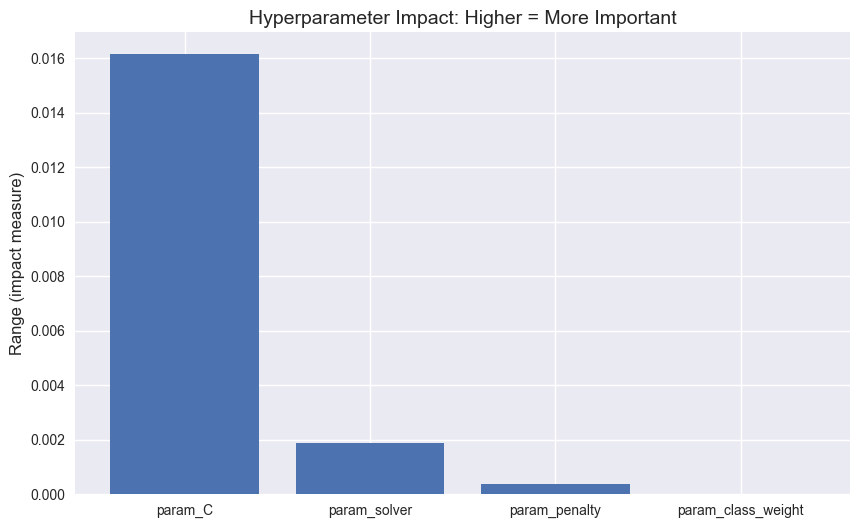

In [26]:
param_range: dict = {}

for param in ["param_C", "param_solver", "param_penalty", "param_class_weight"]:
    means = results_df.groupby(param)["mean_test_score"].mean()
    param_range[param] = means.max() - means.min()

plt.figure(figsize=(10, 6))
bars = plt.bar(list(param_range.keys()), list(param_range.values()))
plt.ylabel("Range (impact measure)", fontsize=12)
plt.title("Hyperparameter Impact: Higher = More Important", fontsize=14)
plt.show()

Which hyperparameters have the most impact?<br>
Impact: 'param_C' (0.0161) -> 'param_solver' (0.00188) -> 'param_penalty' (0.000386) -> 'param_class_weight' (0.0)

#### 10. Check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini.<br>Do you see a drop in performance when comparing the valid quality to the test quality?<br> Is your model overfitted or not? Explain.

In [27]:
# best models
LogReg = LogisticRegression(
    C=best_param.iloc[0]["param_C"],
    penalty=best_param.iloc[0]["param_penalty"],
    solver=best_param.iloc[0]["param_solver"],
    class_weight=best_param.iloc[0]["param_class_weight"],
    random_state=42,
)
GNB = GaussianNB()

f_out: dict = {
    "Model": [
        "LogReg_l1",
        "GaussianNB",
    ],
    "Train_Gini": [],
    "Valid_Gini": [],
    "Test_Gini": [],
    "Train –> Valid diff, %": [],
    "Valid –> Test diff, %": [],
}

for num, model in enumerate((LogReg, GNB)):
    model.fit(X_train.loc[:, best_features], y_train)

    for x, y, name in (
        (X_train.loc[:, best_features], y_train, "Train"),
        (X_valid.loc[:, best_features], y_valid, "Valid"),
        (X_test.loc[:, best_features], y_test, "Test"),
    ):
        y_pred = model.predict_proba(X=x)[:, 1]
        f_out[f"{name}_Gini"].append(gini_score_sk(y_true=y, y_score=y_pred))

    train_valid = f_out["Valid_Gini"][num] / f_out["Train_Gini"][num]
    valid_test = f_out["Test_Gini"][num] / f_out["Valid_Gini"][num]

    f_out["Train –> Valid diff, %"].append(round(train_valid - 1, 3) * 100)
    f_out["Valid –> Test diff, %"].append(round(valid_test - 1, 3) * 100)

pd.DataFrame(f_out)

,Model,Train_Gini,Valid_Gini,Test_Gini,"Train –> Valid diff, %","Valid –> Test diff, %"
0,LogReg_l1,0.4853,0.4815,0.4878,-0.8,1.3
1,GaussianNB,0.4765,0.4731,0.4903,-0.7,3.6


Best model in case of stability - LogReg_l1, which is more stable across all three datasets.<br><br>
Do you see a drop in performance when comparing the valid quality to the test quality? No, it's the other way around.
<br> Is your model overfitted or not? Explain. No, the model is not overfitted: all scores are in small range
<br>Big drop in perfomance = overfitting

#### 11.1 Implement calculation of Recall, Precision, F1 score and AUC PR metrics

### Recall = ${T_p \over {T_p + F_n}}$

In [28]:
def recall(y_true, y_pred):
    # recall_score
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    True_Pos = np.sum((y_true == 1) & (y_pred == 1))
    False_Neg = np.sum((y_true == 1) & (y_pred == 0))
    return True_Pos / (True_Pos + False_Neg) if (True_Pos + False_Neg) > 0 else 0

### Precision = ${T_p \over {T_p + F_p}}$

In [29]:
def precision(y_true, y_pred):
    # precision_score
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    True_Pos = np.sum((y_true == 1) & (y_pred == 1))
    False_Pos = np.sum((y_true == 0) & (y_pred == 1))
    return True_Pos / (True_Pos + False_Pos) if (True_Pos + False_Pos) > 0 else 0

#### $`F_{\beta} = (1 + \beta^2) \cdot {precision \cdot recall \over {\beta^2 \cdot precision + recall}}`$<br><br>$F1 = 2 \cdot {precision \cdot recall \over {precision + recall}}$

In [30]:
def f1_score_my(y_true, y_pred):
    prec = precision(y_true=y_true, y_pred=y_pred)
    rec = recall(y_true=y_true, y_pred=y_pred)

    nominator = 2 * prec * rec
    denominator = prec + rec

    return nominator / denominator if denominator > 0 else 0

#### $AUC\text{-}PR = \int_{0}^{1} P(R)  dR$


In [31]:
def auc_pr_sklearn(y_true, y_score):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    return auc(recall, precision)

In [32]:
def auc_pr(y_true, y_score):
    sorted_idx = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[sorted_idx]
    y_score_sorted = y_score[sorted_idx]

    thresholds = np.unique(y_score_sorted)
    thresholds = np.append(thresholds, thresholds[-1] + 1)

    prec_val, rec_val = [], []

    for threshold in thresholds:
        y_pred = y_score_sorted >= threshold

        prec = precision(y_true_sorted, y_pred)
        rec = recall(y_true_sorted, y_pred)

        prec_val.append(prec)
        rec_val.append(rec)

    # for proper AUC calculation
    rec_val.append(0.0)
    prec_val.append(1.0)

    sorted_indices = np.argsort(rec_val)
    rec_val = np.array(rec_val)[sorted_indices]
    prec_val = np.array(prec_val)[sorted_indices]

    # or use auc_score = np.trapz(prec_val, rec_val)
    auc_score = 0.0
    for i in range(1, len(rec_val)):
        width = rec_val[i] - rec_val[i - 1]
        height = (prec_val[i] + prec_val[i - 1]) / 2
        auc_score += width * height

    return auc_score

#### $Average Precision (AP) = \sum_{n} (R_n - R_{n-1}) P_n$

In [33]:
def avg_prec_score(y_true, y_score):
    idx = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[idx]

    cum_positives = np.cumsum(y_true_sorted)

    precision_at_k = cum_positives / (np.arange(len(y_true_sorted)) + 1)

    avg_prec = np.sum(precision_at_k * y_true_sorted) / np.sum(y_true_sorted)

    return avg_prec if np.sum(y_true_sorted) > 0 else 0.0

In [34]:
out: pd.DataFrame = pd.DataFrame({"Sklearn": [], "my": []})
y_pred = LogReg.predict(X=X_test.loc[:, best_features])

metrics = (
    (precision_score, precision),
    (recall_score, recall),
    (f1_score, f1_score_my),
    (auc_pr_sklearn, auc_pr),
    (average_precision_score, avg_prec_score),
)

for num, (sklearn_sc, my_sc) in enumerate(metrics):
    if num in (3, 4):
        y_pred = LogReg.predict_proba(X=X_test.loc[:, best_features])[:, 1]
    sk = round(sklearn_sc(y_test, y_pred), 4)
    my = round(my_sc(y_test, y_pred), 4)

    out.loc[my_sc.__name__] = {"Sklearn": sk, "my": my}

out

,Sklearn,my
precision,0.2407,0.2407
recall,0.6280,0.6280
f1_score_my,0.3480,0.3480
auc_pr,0.4441,0.4439
avg_prec_score,0.4442,0.4442


#### 11.2 Compare your algorithms on the test dataset using AUC PR metric.

In [35]:
out: pd.DataFrame = pd.DataFrame(
    {
        "model": [],
        "Gini_test": [],
        "AUC_PR_test": [],
    }
)

for model in [
    LogReg,
    GaussianNB(),
    KNeighborsClassifier(),
]:

    model.fit(X=X_train.loc[:, best_features], y=y_train)
    y_pred = model.predict_proba(X=X_test.loc[:, best_features])[:, 1]
    out.loc[len(out)] = {
        "model": model.__class__.__name__,
        "Gini_test": gini_score_sk(y_true=y_test, y_score=y_pred),
        "AUC_PR_test": round(auc_pr_sklearn(y_true=y_test.values, y_score=y_pred), 4),
    }

out.reset_index(drop=True)

,model,Gini_test,AUC_PR_test
0,LogisticRegression,0.4878,0.4441
1,GaussianNB,0.4903,0.4501
2,KNeighborsClassifier,0.3258,0.3774


#### 12. Which hard label metric do you prefer for the task of detecting "lemon" cars?

Approach: strict threshold like in classifier.predict_proba > 50-90% threshold (voting)<br>
Metric: Precision (TP / (TP + FP))

In [36]:
total_seconds = time.time() - notebook_time
print(f"{total_seconds // 60}m {(total_seconds % 60):.1f}s")

7.0m 25.4s


#### * Sources
- https://education.yandex.ru/handbook/ml/article/generativnyj-podhod-k-klassifikacii
- https://education.yandex.ru/handbook/ml/article/linear-models
- https://www.kaggle.com/code/fareselmenshawii/knn-from-scratch#How-the-algorithm-works
- https://alexanderdyakonov.wordpress.com/2017/07/28/auc-roc-%D0%BF%D0%BB%D0%BE%D1%89%D0%B0%D0%B4%D1%8C-%D0%BF%D0%BE%D0%B4-%D0%BA%D1%80%D0%B8%D0%B2%D0%BE%D0%B9-%D0%BE%D1%88%D0%B8%D0%B1%D0%BE%D0%BA/